In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
CSV = "/Users/user/data/research/proton-deuteron/csv/length.csv"

In [3]:
df = pd.read_csv(CSV)

In [4]:
df

,run,subrun,event,ntracks_reco,track_index,trklength,trkWCtoTPCMatch,wctrk_picky,beamline_mass
0,8675,12,1249,1,0,31.53803,1,0,1082.47681
1,8675,12,1250,23,0,27.51520,0,0,120.62389
2,8675,12,1250,23,1,7.06335,0,0,120.62389
3,8675,12,1250,23,2,18.30797,0,0,120.62389
4,8675,12,1250,23,3,12.67128,0,0,120.62389
...,...,...,...,...,...,...,...,...,...
3983859,9781,133,21623,7,2,52.07600,0,0,-70.84017
3983860,9781,133,21623,7,3,77.36593,0,0,-70.84017
3983861,9781,133,21623,7,4,10.73799,0,0,-70.84017
3983862,9781,133,21623,7,5,5.38976,0,0,-70.84017


In [5]:
unique = df[['run', 'subrun', 'event']].drop_duplicates()
unique

,run,subrun,event
0,8675,12,1249
1,8675,12,1250
24,8675,12,1256
26,8675,12,1257
28,8675,12,1258
...,...,...,...
3983847,9781,133,21589
3983849,9781,133,21596
3983851,9781,133,21614
3983855,9781,133,21621


In [6]:
selection = df[(df['wctrk_picky'] == 1) & (df['beamline_mass'] > 600) & (df['beamline_mass'] < 1600)]           #  & (df['ntracks_reco'] == 1)

In [7]:
selection

,run,subrun,event,ntracks_reco,track_index,trklength,trkWCtoTPCMatch,wctrk_picky,beamline_mass
55,8675,12,1268,6,0,84.64694,0,1,920.23090
56,8675,12,1268,6,1,82.94527,0,1,920.23090
57,8675,12,1268,6,2,78.60595,0,1,920.23090
58,8675,12,1268,6,3,72.54380,0,1,920.23090
59,8675,12,1268,6,4,16.92252,1,1,920.23090
...,...,...,...,...,...,...,...,...,...
3983814,9781,130,21143,6,3,6.07802,0,1,906.21838
3983815,9781,130,21143,6,4,2.92476,0,1,906.21838
3983816,9781,130,21143,6,5,2.28671,0,1,906.21838
3983828,9781,133,21574,2,0,41.32235,0,1,964.97107


In [8]:
events = selection[['run', 'subrun', 'event']].drop_duplicates().reset_index(drop=True)
events.to_csv('/Users/user/data/research/proton-deuteron/csv/picky_1track_protons.csv', index=False)

In [9]:
events

,run,subrun,event
0,8675,12,1268
1,8675,12,1290
2,8675,12,1295
3,8675,12,1306
4,8675,12,1307
...,...,...,...
70876,9781,127,20677
70877,9781,127,20688
70878,9781,130,21116
70879,9781,130,21143


In [10]:
selection[selection.duplicated(subset=["run", "subrun", "event"])]

,run,subrun,event,ntracks_reco,track_index,trklength,trkWCtoTPCMatch,wctrk_picky,beamline_mass
56,8675,12,1268,6,1,82.94527,0,1,920.23090
57,8675,12,1268,6,2,78.60595,0,1,920.23090
58,8675,12,1268,6,3,72.54380,0,1,920.23090
59,8675,12,1268,6,4,16.92252,1,1,920.23090
60,8675,12,1268,6,5,3.52408,0,1,920.23090
...,...,...,...,...,...,...,...,...,...
3983813,9781,130,21143,6,2,22.20228,1,1,906.21838
3983814,9781,130,21143,6,3,6.07802,0,1,906.21838
3983815,9781,130,21143,6,4,2.92476,0,1,906.21838
3983816,9781,130,21143,6,5,2.28671,0,1,906.21838


Text(0.5, 1.0, 'No Match, Picky and 1 Reco Track Proton Events')

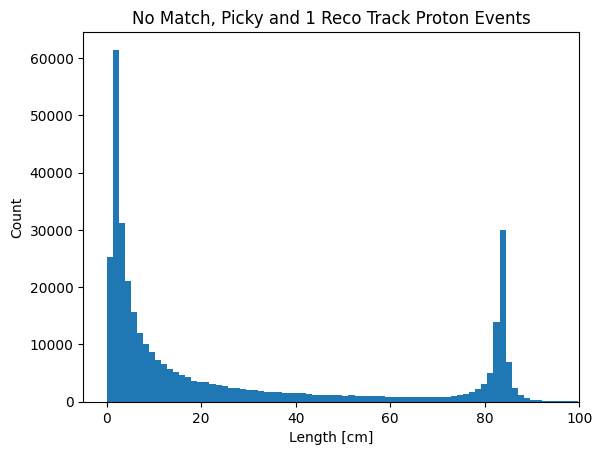

In [11]:
plt.hist(selection['trklength'], bins='auto')
plt.xlim(-5, 100)
plt.xlabel('Length [cm]')
plt.ylabel('Count')
plt.title('No Match, Picky and 1 Reco Track Proton Events')

Text(0.5, 1.0, 'No Match, Picky and 1 Reco Track Proton Events')

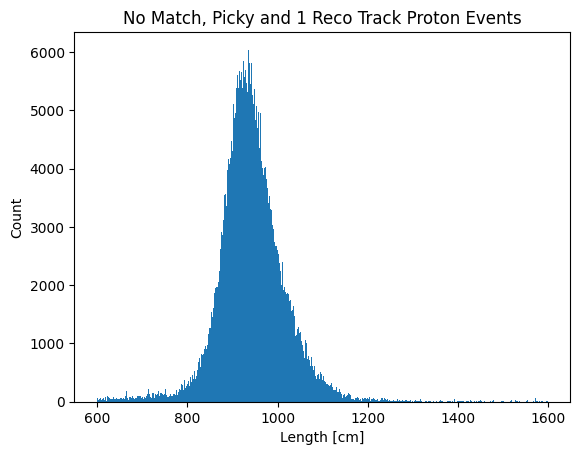

In [12]:
plt.hist(selection['beamline_mass'], bins='auto')
plt.xlabel('Length [cm]')
plt.ylabel('Count')
plt.title('No Match, Picky and 1 Reco Track Proton Events')

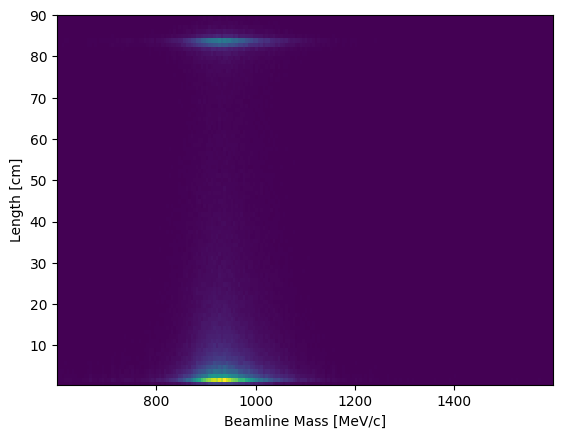

In [13]:
from matplotlib.colors import LogNorm

mass = selection['beamline_mass'].values
length = selection['trklength'].values

plt.hist2d(mass, length, bins=[200, 200]) 
plt.ylim(0.5, 90)

plt.xlabel('Beamline Mass [MeV/c]')
plt.ylabel('Length [cm]')
plt.show()

In [14]:
current = df[(df['wctrk_picky'] == 1) & (df['trkWCtoTPCMatch'] == 1) & (df['ntracks_reco'] == 1) & (df['ntracks_reco'] == 1) & (df['beamline_mass'] > 600) & (df['beamline_mass'] < 1600)]

In [15]:
min(selection['trklength'])

0.0

In [16]:
min(current['trklength'])

4.01748

Text(0.5, 1.0, 'Match, Picky and 1 Reco Track Proton Events')

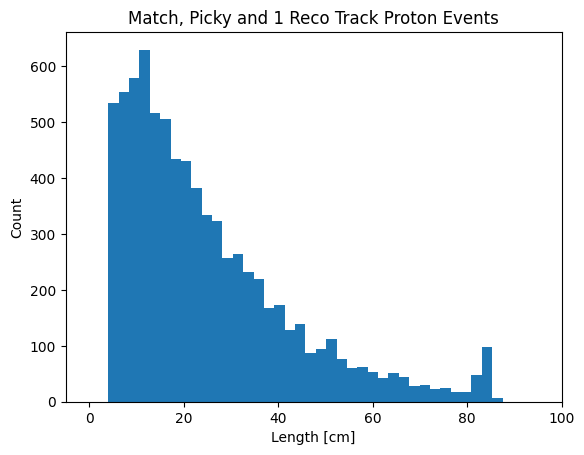

In [17]:
plt.hist(current['trklength'], bins='auto')
plt.xlim(-5, 100)
plt.xlabel('Length [cm]')
plt.ylabel('Count')
plt.title('Match, Picky and 1 Reco Track Proton Events')

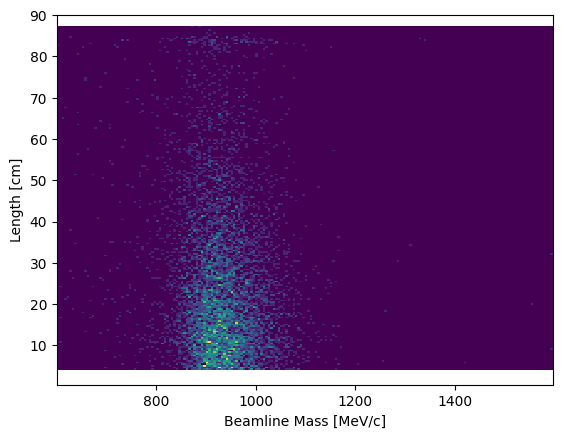

In [18]:
mass = current['beamline_mass'].values
length = current['trklength'].values

plt.hist2d(mass, length, bins=[200, 200]) 
plt.ylim(0.5, 90)

plt.xlabel('Beamline Mass [MeV/c]')
plt.ylabel('Length [cm]')
plt.show()

In [29]:
import uproot

import numpy as np
import pandas as pd
import awkward as ak
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
PATH = "/Volumes/easystore/rawExtracted_lariat_digit_r009783_sr0044_20160720T062008_TimestampFilter_20251128T110213.root"

In [32]:
file = uproot.open(PATH)
file.keys(), file.classnames()

(['ana;1', 'ana/raw;255', 'ana/raw;254'],
 {'ana;1': 'TDirectory', 'ana/raw;255': 'TTree', 'ana/raw;254': 'TTree'})

In [33]:
# Open tree
tree = file["ana/raw"]
tree.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
run                  | int32_t                  | AsDtype('>i4')
subrun               | int32_t                  | AsDtype('>i4')
event                | int32_t                  | AsDtype('>i4')
evttime              | double                   | AsDtype('>f8')
raw_rawadc           | std::vector<int16_t>     | AsJagged(AsDtype('>i2'), he...
raw_channel          | std::vector<uint32_t>    | AsJagged(AsDtype('>u4'), he...


In [62]:
i = 7  # choose the event you want

data = tree.arrays(
    ["raw_rawadc", "raw_channel", "run", "subrun", "event"],
    entry_start=i,
    entry_stop=i+1,
    library="ak",
)

adc_data = ak.to_numpy(data[0]["raw_rawadc"])
channel_map = ak.to_numpy(data[0]["raw_channel"])
adc_data, channel_map, adc_data.shape, channel_map.shape

num_channels_in_event = len(channel_map) # 480 - 240 in collection, 240 in induction - number of wires
num_ticks = len(adc_data) // num_channels_in_event # 480 wires, record a sample 3072 times. 
num_channels_in_event, num_ticks

# Turning flat ADC array into 2D array. Each 3072 values are one wire, over 3072 time ticks. Wire are not ordered, but their index is given in channel_map.

adc_data2d = adc_data.reshape((num_channels_in_event, num_ticks)) # wire numbers not ordered, every 3072 is one channel

collection = np.zeros((240, num_ticks))
induction = np.zeros((240, num_ticks))

# Organising the wires properly and data input into collection and induction. 

for i, channel_num in enumerate(channel_map):
    if 0 <= channel_num < 240:
        wire_index = channel_num
        induction[wire_index, :] = adc_data2d[i, :] # each row is a channel/wire, going 0 -> 239 (ordered) we have 240 rows, each with 3072 columns (time)
    if 240 <= channel_num < 480:
        wire_index = channel_num - 240
        collection[wire_index, :] = adc_data2d[i, :]  # each row is a channel/wire, going 240 -> 479 (orded)

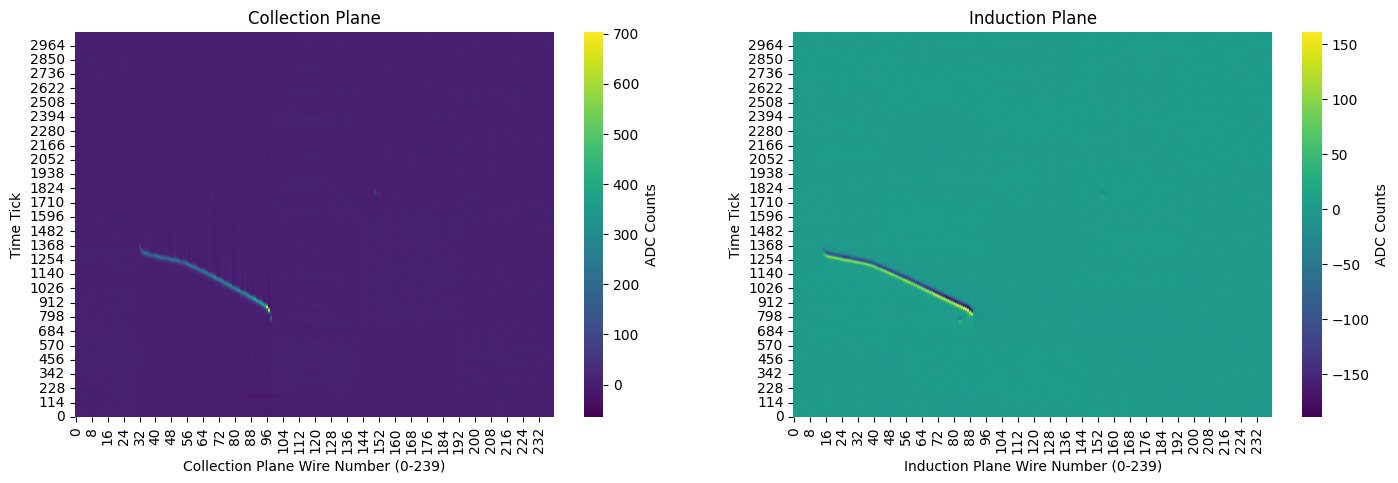

In [63]:
# Event displays

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))


sns.heatmap(collection.T, cmap="viridis", cbar_kws={'label': 'ADC Counts'}, ax=ax1)
ax1.set_xlabel("Collection Plane Wire Number (0-239)")
ax1.set_ylabel("Time Tick")
ax1.set_title("Collection Plane")
ax1.invert_yaxis()

sns.heatmap(induction.T, cmap='viridis', cbar_kws={'label': 'ADC Counts'}, ax=ax2)
ax2.set_xlabel("Induction Plane Wire Number (0-239)")
ax2.set_ylabel("Time Tick")
ax2.set_title("Induction Plane")
ax2.invert_yaxis()